In [15]:
import pandas as pd

In [13]:
from data import get_data
df = get_data()
df.head()

,batch_id,used_bikes,id,batch_id,timestamp,temperature,relative_humidity,apparent_temperature,is_day,surface_pressure,pressure_msl,precipitation,rain,snowfall,showers,cloud_cover,wind_speed,wind_direction,weather_code
0,1,0.5132,1,1,2026-01-03 11:00:00,-5.5425,49,-10.524596,False,1007.821167,1014.400024,0.0,0.0,0.0,0.0,0,9.746631,274.236328,0
1,2,0.5146,2,2,2026-01-03 12:00:00,-6.2425,53,-11.055573,False,1008.598572,1015.200012,0.0,0.0,0.0,0.0,0,8.707238,262.875092,0
2,3,0.5155,3,3,2026-01-03 13:00:00,-5.7425,52,-10.650141,True,1009.604492,1016.200012,0.0,0.0,0.0,0.0,100,9.449572,252.255234,3
3,4,0.5164,4,4,2026-01-03 14:00:00,-4.1425,45,-9.299176,True,1009.445007,1016.000000,0.0,0.0,0.0,0.0,100,11.043261,289.025696,3
4,5,0.5181,5,5,2026-01-03 16:00:00,-2.1425,45,-7.358112,True,1007.903442,1014.400024,0.0,0.0,0.0,0.0,100,12.224107,283.627014,3


In [16]:
df['used_bikes'] = pd.to_numeric(df['used_bikes'])

In [51]:
df['used_bikes'].max()

Decimal('0.5424')

In [52]:
df['used_bikes'].min()

Decimal('0.4999')

In [29]:
df.drop(['batch_id', 'id'], axis=1, inplace=True)

In [30]:
# Extract year, month, day, and hour
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour

In [31]:
df.head()

,used_bikes,timestamp,temperature,relative_humidity,apparent_temperature,is_day,surface_pressure,pressure_msl,precipitation,rain,snowfall,showers,cloud_cover,wind_speed,wind_direction,weather_code,year,month,day,hour
0,0.5132,2026-01-03 11:00:00,-5.5425,49,-10.524596,False,1007.821167,1014.400024,0.0,0.0,0.0,0.0,0,9.746631,274.236328,0,2026,1,3,11
1,0.5146,2026-01-03 12:00:00,-6.2425,53,-11.055573,False,1008.598572,1015.200012,0.0,0.0,0.0,0.0,0,8.707238,262.875092,0,2026,1,3,12
2,0.5155,2026-01-03 13:00:00,-5.7425,52,-10.650141,True,1009.604492,1016.200012,0.0,0.0,0.0,0.0,100,9.449572,252.255234,3,2026,1,3,13
3,0.5164,2026-01-03 14:00:00,-4.1425,45,-9.299176,True,1009.445007,1016.000000,0.0,0.0,0.0,0.0,100,11.043261,289.025696,3,2026,1,3,14
4,0.5181,2026-01-03 16:00:00,-2.1425,45,-7.358112,True,1007.903442,1014.400024,0.0,0.0,0.0,0.0,100,12.224107,283.627014,3,2026,1,3,16


In [32]:
df.drop(['timestamp'], axis = 1, inplace=True)
df['used_bikes'] = df['used_bikes'] * 100

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
df

,used_bikes,temperature,relative_humidity,apparent_temperature,is_day,surface_pressure,pressure_msl,precipitation,rain,snowfall,showers,cloud_cover,wind_speed,wind_direction,weather_code,year,month,day,hour
0,51.3200,-5.5425,49,-10.524596,False,1007.821167,1014.400024,0.0,0.0,0.00,0.0,0,9.746631,274.236328,0,2026,1,3,11
1,51.4600,-6.2425,53,-11.055573,False,1008.598572,1015.200012,0.0,0.0,0.00,0.0,0,8.707238,262.875092,0,2026,1,3,12
2,51.5500,-5.7425,52,-10.650141,True,1009.604492,1016.200012,0.0,0.0,0.00,0.0,100,9.449572,252.255234,3,2026,1,3,13
3,51.6400,-4.1425,45,-9.299176,True,1009.445007,1016.000000,0.0,0.0,0.00,0.0,100,11.043261,289.025696,3,2026,1,3,14
4,51.8100,-2.1425,45,-7.358112,True,1007.903442,1014.400024,0.0,0.0,0.00,0.0,100,12.224107,283.627014,3,2026,1,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,50.9400,-0.4925,93,-3.384385,False,1012.513306,1019.000000,0.0,0.0,0.00,0.0,100,3.758510,286.699310,3,2026,1,18,8
181,51.0500,-0.5925,96,-3.171809,False,1012.908264,1019.400024,0.0,0.0,0.00,0.0,100,1.938659,201.801468,3,2026,1,18,10
182,50.9400,-0.3925,96,-3.187994,False,1011.820007,1018.299988,0.1,0.1,0.00,0.0,100,3.617955,174.289505,51,2026,1,18,12
183,50.9100,0.4075,99,-2.412985,True,1011.540833,1018.000000,0.2,0.1,0.07,0.0,100,5.052841,274.085541,73,2026,1,18,14


In [35]:
y = df['used_bikes']
X = df.drop(['used_bikes'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [36]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
mean_absolute_error(y_test, model.predict(X_test))

0.4472875000000044

In [38]:
mean_squared_error(y_test, model.predict(X_test))

0.29257200517857623

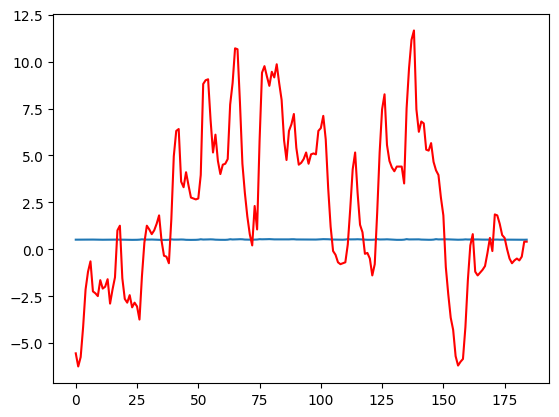

In [5]:
import matplotlib.pyplot as plt
plt.plot(df['used_bikes'])
plt.plot(df['temperature'], color='red')

## pomysl 2

In [40]:
from data import get_data
df = get_data()
df.head()

,batch_id,used_bikes,id,batch_id,timestamp,temperature,relative_humidity,apparent_temperature,is_day,surface_pressure,pressure_msl,precipitation,rain,snowfall,showers,cloud_cover,wind_speed,wind_direction,weather_code
0,1,0.5132,1,1,2026-01-03 11:00:00,-5.5425,49,-10.524596,False,1007.821167,1014.400024,0.0,0.0,0.0,0.0,0,9.746631,274.236328,0
1,2,0.5146,2,2,2026-01-03 12:00:00,-6.2425,53,-11.055573,False,1008.598572,1015.200012,0.0,0.0,0.0,0.0,0,8.707238,262.875092,0
2,3,0.5155,3,3,2026-01-03 13:00:00,-5.7425,52,-10.650141,True,1009.604492,1016.200012,0.0,0.0,0.0,0.0,100,9.449572,252.255234,3
3,4,0.5164,4,4,2026-01-03 14:00:00,-4.1425,45,-9.299176,True,1009.445007,1016.000000,0.0,0.0,0.0,0.0,100,11.043261,289.025696,3
4,5,0.5181,5,5,2026-01-03 16:00:00,-2.1425,45,-7.358112,True,1007.903442,1014.400024,0.0,0.0,0.0,0.0,100,12.224107,283.627014,3


In [41]:
df.drop(['batch_id', 'id'], axis=1, inplace=True)
# Extract year, month, day, and hour
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df.drop(['timestamp'], axis = 1, inplace=True)
df['used_bikes'] = df['used_bikes'] * 100

In [43]:
y = df['apparent_temperature']
X = df.drop(['apparent_temperature', 'used_bikes'], axis = 1)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
mean_squared_error(y_test, model.predict(X_test))

0.8105479655925112

In [46]:
pred = model.predict(X_test)

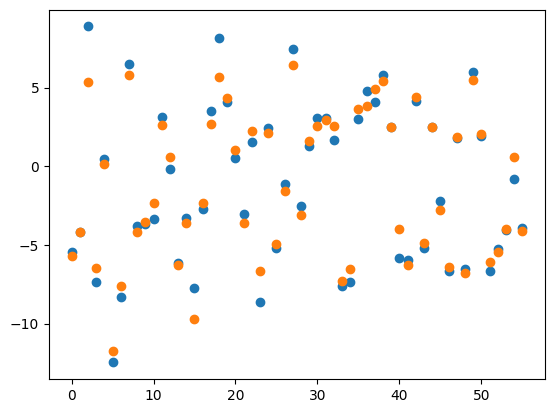

In [49]:
import matplotlib.pyplot as plt
tmp = [i for i in range(len(y_test))]
plt.scatter(tmp, y_test)
plt.scatter(tmp, pred)
# ax.plot(np.array([4, 8]), np.array([4, 8]), color='red')

In [17]:
# Source - https://stackoverflow.com/a
# Posted by Alpha, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-20, License - CC BY-SA 4.0

def plot_multi(data, cols=None, spacing=.1, **kwargs):

    from pandas.plotting._matplotlib.style import get_standard_colors

    # Get default color style from pandas - can be changed to any other color list
    if cols is None: cols = data.columns
    if len(cols) == 0: return
    colors = get_standard_colors(num_colors=len(cols))

    # First axis
    ax = data.loc[:, cols[0]].plot(label=cols[0], color=colors[0], **kwargs)
    ax.set_ylabel(ylabel=cols[0])
    lines, labels = ax.get_legend_handles_labels()

    for n in range(1, len(cols)):
        # Multiple y-axes
        ax_new = ax.twinx()
        ax_new.spines['right'].set_position(('axes', 1 + spacing * (n - 1)))
        data.loc[:, cols[n]].plot(ax=ax_new, label=cols[n], color=colors[n % len(colors)], **kwargs)
        ax_new.set_ylabel(ylabel=cols[n])
        
        # Proper legend position
        line, label = ax_new.get_legend_handles_labels()
        lines += line
        labels += label

    ax.legend(lines, labels, loc=0)
    return ax


In [ ]:
ax = data.loc[:, cols[0]].plot(label=cols[0], color=colors[0], **kwargs)
ax.set_ylabel(ylabel=cols[0])
lines, labels = ax.get_legend_handles_labels()

In [18]:
df.dtypes

batch_id                         int64
used_bikes                     float64
id                               int64
batch_id                         int64
timestamp               datetime64[ns]
temperature                    float64
relative_humidity                int64
apparent_temperature           float64
is_day                            bool
surface_pressure               float64
pressure_msl                   float64
precipitation                  float64
rain                           float64
snowfall                       float64
showers                        float64
cloud_cover                      int64
wind_speed                     float64
wind_direction                 float64
weather_code                     int64
dtype: object

<Axes: ylabel='used_bikes'>

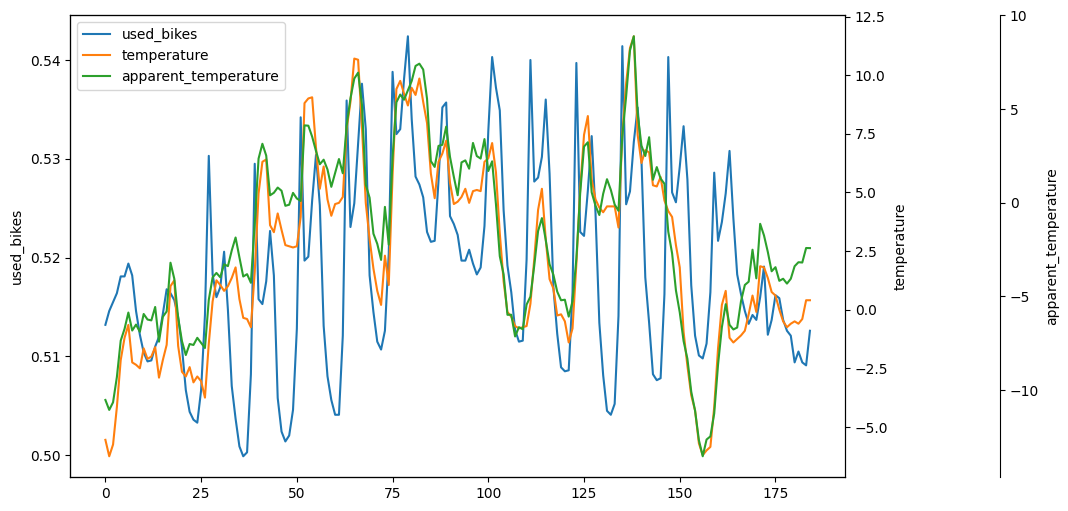

In [20]:
plot_multi(df, cols=['used_bikes', 'temperature', 'apparent_temperature'], spacing=0.2, figsize=(10,6))

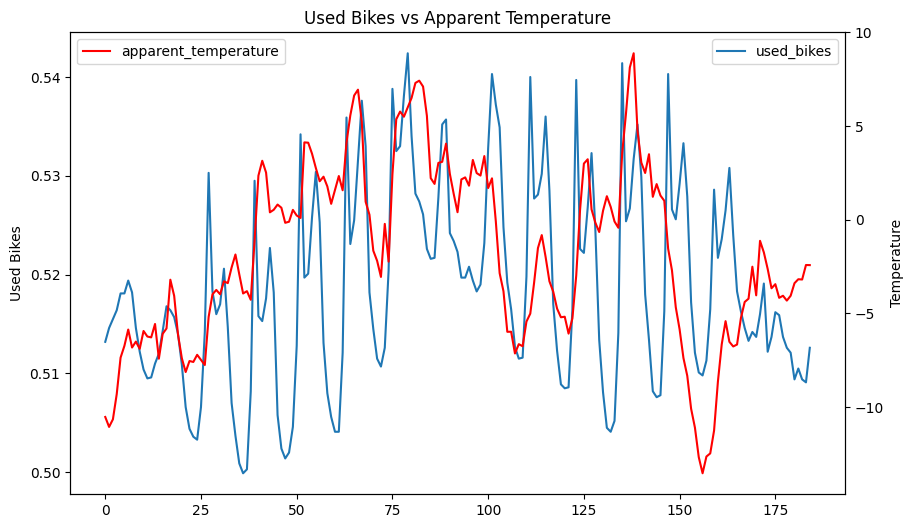

In [24]:
import matplotlib.pyplot as plt

# df is your pandas DataFrame
# df.index should be a datetime index (or already sorted)

ax = df.plot(
    y="used_bikes",
    figsize=(10, 6),
    legend=True
)

ax.set_ylabel("Used Bikes")

# Create second y-axis
ax2 = ax.twinx()

df.plot(
    y="apparent_temperature",
    ax=ax2,
    legend=True,
    color = 'red'
)

# df.plot(y='temperature', ax=ax2, legend=True, color='green')

ax2.set_ylabel("Temperature")

plt.title("Used Bikes vs Apparent Temperature")
plt.show()
